# Session 3: XGBoost & SHAP for Wheat Yield Prediction


**Learning objectives:**
- Understand the difference between bagging (RF) and boosting (XGBoost)
- Train XGBoost with early stopping
- Use SHAP to explain individual predictions
- Compare RF vs XGBoost with same features

**Session plan:**
1. Setup (same data as Sessions 1–2)
2. **Model:** XGBoost with monthly features → compare with RF monthly
3. SHAP explanations
4. Final model comparison
5. Summary

---

## Part 1: Setup 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
import time
import warnings
import joblib, os
warnings.filterwarnings('ignore')

print(f"XGBoost version: {xgb.__version__}")




XGBoost version: 3.2.0


In [3]:
DATA_PATH = './data/wheat_features.parquet' 
df = pd.read_parquet(DATA_PATH)


In [4]:
# Flag suspect

suspect = (df['wheat_yield'] < 0.01) & (df['sowing_doy'] > 0)
print(f"Suspect zero-yield rows (sown but yield=0): {suspect.sum()}")
 
#  Window-median replacement
WINDOW = 3   # years on each side
 
def replace_zeros_window_median(series: pd.Series,
                                 suspect_mask: pd.Series,
                                 window: int = WINDOW) -> pd.Series:
    """
    For each flagged position, compute the median of up to `window`
    valid (non-zero, non-NaN) neighbours on each side in the time series.
    Falls back to the cell-wide positive median if fewer than 2 neighbours exist.
    """
    s = series.copy().astype(float)
    fallback_median = s[s > 0].median()
 
    for idx in s.index[suspect_mask.reindex(s.index, fill_value=False)]:
        pos = s.index.get_loc(idx)
 
        left  = [v for v in s.iloc[max(0, pos - window): pos]        if v > 0]
        right = [v for v in s.iloc[pos + 1: pos + 1 + window]        if v > 0]
        neighbours = left + right
 
        if len(neighbours) >= 2:
            s.iloc[pos] = np.median(neighbours)
        else:
            #  not enough neighbours → use cell-wide median
            s.iloc[pos] = fallback_median
 
    return s
 
 
df['wheat_yield'] = (
    df.groupby(['lat', 'lon'], group_keys=False)
    .apply(lambda g: replace_zeros_window_median(
        g['wheat_yield'],
        suspect.loc[g.index]
    ))
)


Suspect zero-yield rows (sown but yield=0): 464


In [ ]:
# ── Same setup as Session 2 ──

# Metrics 
def concordance_cc(actual, predicted):
    mean_act  = np.mean(actual)
    mean_pred = np.mean(predicted)
    var_act   = np.var(actual)
    var_pred  = np.var(predicted)
    covariance = np.mean((actual - mean_act) * (predicted - mean_pred))
    return (2 * covariance) / (var_act + var_pred + (mean_act - mean_pred)**2)

def print_metrics(name, actual, predicted):
    r2   = r2_score(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    bias = np.mean(predicted - actual)
    lccc = concordance_cc(actual, predicted)
    print(f"  {name:<30s} R2={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}  Bias={bias:+.3f}  LCCC={lccc:.3f}")
    return {"name": name, "R2": r2, "RMSE": rmse, "MAE": mae, "Bias": bias, "LCCC": lccc}

FEATURE_COLS = ['pawc_0_30_mm',  'ph_0_30','rain_preseason', 'rain_early', 'rain_late',
                'gdd_may_nov', 'frost_days_aug_oct', 'heat_days_aug_oct',  'rad_aug_oct', 'fasw_mean_aug_oct']


monthly_rain = [c for c in df.columns if c.startswith("rain_m") or c.startswith("rain_mpre")]
monthly_rad  = [c for c in df.columns if c.startswith("rad_sum_m")]
monthly_fasw = [c for c in df.columns if c.startswith("fasw_mean_m") and "aug" not in c]
monthly_gdd  = [c for c in df.columns if c.startswith("gdd_m")]
soil_feats   = ["pawc_0_30_mm", "ph_0_30"]
augoct_feats = [c for c in ["frost_days_aug_oct","heat_days_aug_oct",
                             "rad_aug_oct","fasw_mean_aug_oct"] if c in df.columns]

MONTHLY_FEATURES = soil_feats + monthly_rain + monthly_rad + monthly_fasw + monthly_gdd + augoct_feats
MONTHLY_FEATURES = [f for f in MONTHLY_FEATURES if f in df.columns]

#  Temporal split 
train = df[df['year'] <= 2018]
test  = df[df['year'] >= 2019]
y_train   = train['wheat_yield'].values.astype(np.float32)
actual_test = test['wheat_yield'].values.asypte(np.float32)

print(f"Simple features:  {len(FEATURE_COLS)}")
print(f"Monthly features: {len(MONTHLY_FEATURES)}")
print(f"Train: {train.year.min()}-{train.year.max()} ({len(train):,} rows)")
print(f"Test:  {test.year.min()}-{test.year.max()}  ({len(test):,} rows)")

Simple features:  10
Monthly features: 49
Train: 1989-2018 (213,360 rows)
Test:  2019-2020  (14,224 rows)




### Bagging vs Boosting — Quick Recap

| | Random Forest (Bagging) | XGBoost (Boosting) |
|---|---|---|
| **Strategy** | Train trees independently, average them | Train trees sequentially, each fixes previous errors |
| **Each tree fits** | Raw yield | Residuals from all previous trees |
| **Combining** | Average | Sum of corrections |
| **Main goal** | Reduce variance | Reduce bias |




## Monthly features



In [6]:
# Prepare monthly data 
X_train_m = train[MONTHLY_FEATURES].values.astype(np.float32)
X_test_m  = test[MONTHLY_FEATURES].values.astype(np.float32)


for i in range(X_train_m.shape[1]):
    med = np.nanmedian(X_train_m[:, i])
    X_train_m[np.isnan(X_train_m[:, i]), i] = med
    X_test_m[np.isnan(X_test_m[:, i]), i] = med



In [15]:
# Loading the model
rf_m = joblib.load('./models/rf_monthly.joblib')
pred_rf_m = rf_m.predict(X_test_m)
m_rf_m = print_metrics(f"RF ({len(MONTHLY_FEATURES)} feat)", actual_test, pred_rf_m)

  RF (49 feat)                   R2=0.740  RMSE=0.450  MAE=0.356  Bias=+0.112  LCCC=0.837


In [12]:
# ── Basic XGBoost (no tuning) ──
t0 = time.time()
xgb_basic = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=10,
    subsample=0.8,         
    colsample_bytree=0.8,  
    learning_rate=0.1,
    random_state=42,
    n_jobs=2,
    tree_method="hist",
)
xgb_basic.fit(X_train_m, y_train)
dt = time.time() - t0

pred_xgb_basic = xgb_basic.predict(X_test_m)

print(f"=== XGBoost basic, {dt:.1f}s) ===")
m_xgb_basic = print_metrics("XGBoost basic", actual_test, pred_xgb_basic)

=== XGBoost basic, 9.0s) ===
  XGBoost basic                  R2=0.804  RMSE=0.390  MAE=0.300  Bias=+0.043  LCCC=0.881


### Early Stopping — Knowing When to Stop

XGBoost adds trees sequentially. At some point, more trees = overfitting.
**Early stopping** watches a validation set and stops when it stops improving.


In [ ]:
# XGBoost with monthly features + early stopping
X_tr_m, X_val_m, y_tr_m, y_val_m = train_test_split(
    X_train_m, y_train, test_size=0.15, random_state=42
)

xgb_es_m = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    early_stopping_rounds=50,
)
xgb_es_m.fit(X_tr_m, y_tr_m, eval_set=[(X_val_m, y_val_m)], verbose=False)

pred_xgb_m = xgb_es_m.predict(X_test_m)

print(f"Best iteration: {xgb_es_m.best_iteration}")
m_xgb_m = print_metrics(f"XGBoost+ES ({len(MONTHLY_FEATURES)} feat)", actual_test, pred_xgb_m)

Best iteration: 99
  XGBoost+ES (49 feat)           R2=0.791  RMSE=0.404  MAE=0.311  Bias=+0.067  LCCC=0.874


In [16]:
#  RF vs XGBoost 
print("=" * 80)
print("FULL COMPARISON: RF vs XGBoost x Simple vs Monthly features")
print("=" * 80)
print(f"{'Model':<35s} {'#Feat':>5s} {'R2':>6s} {'RMSE':>7s} {'MAE':>7s} {'Bias':>7s} {'LCCC':>6s}")
print("-" * 80)
for m, nf in [(m_rf_m, len(MONTHLY_FEATURES)),  (m_xgb_basic,  len(MONTHLY_FEATURES)), (m_xgb_m, len(MONTHLY_FEATURES))]:
    print(f"{m['name']:<35s} {nf:>5d} {m['R2']:6.3f} {m['RMSE']:7.3f} {m['MAE']:7.3f} {m['Bias']:+7.3f} {m['LCCC']:6.3f}")
print()



FULL COMPARISON: RF vs XGBoost x Simple vs Monthly features
Model                               #Feat     R2    RMSE     MAE    Bias   LCCC
--------------------------------------------------------------------------------
RF (49 feat)                           49  0.740   0.450   0.356  +0.112  0.837
XGBoost basic                          49  0.804   0.390   0.300  +0.043  0.881
XGBoost+ES (49 feat)                   49  0.791   0.404   0.311  +0.067  0.874



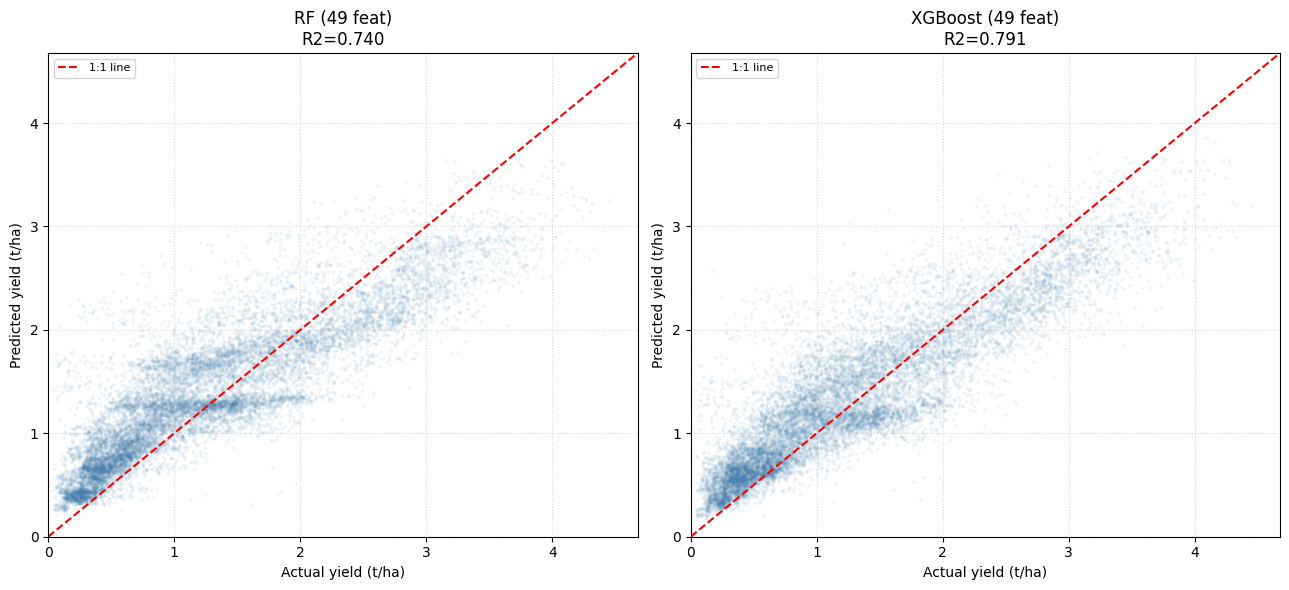

In [46]:
# ── Scatter plots: RF vs XGBoost (monthly features) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (name, pred, r2) in zip(axes, [
    (f"RF ({len(MONTHLY_FEATURES)} feat)", pred_rf_m, m_rf_m['R2']),
    (f"XGBoost ({len(MONTHLY_FEATURES)} feat)", pred_xgb_m, m_xgb_m['R2']),
]):
    ax.scatter(actual_test, pred, alpha=0.05, s=3, color='steelblue')
    lim = max(actual_test.max(), pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='1:1 line')
    ax.set_xlabel('Actual yield (t/ha)')
    ax.set_ylabel('Predicted yield (t/ha)')
    ax.set_title(f'{name}\nR2={r2:.3f}')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)

plt.tight_layout()
plt.show()

In [47]:
# ── Per-year comparison ──
test_years = test['year'].values
print("=== Per-year: RF vs XGBoost (monthly features) ===")
for yr in [2019, 2020]:
    m = test_years == yr
    print(f"\n  Year {yr} (n={m.sum():,}):")
    for name, pred in [(f"RF ({len(MONTHLY_FEATURES)})", pred_rf_m),
                        (f"XGB ({len(MONTHLY_FEATURES)})", pred_xgb_m)]:
        r2 = r2_score(actual_test[m], pred[m])
        rmse = np.sqrt(mean_squared_error(actual_test[m], pred[m]))
        bias = np.mean(pred[m] - actual_test[m])
        print(f"    {name:<25s} R2={r2:.3f}  RMSE={rmse:.3f}  Bias={bias:+.3f}")

=== Per-year: RF vs XGBoost (monthly features) ===

  Year 2019 (n=7,112):
    RF (49)                   R2=0.611  RMSE=0.490  Bias=+0.201
    XGB (49)                  R2=0.678  RMSE=0.445  Bias=+0.127

  Year 2020 (n=7,112):
    RF (49)                   R2=0.815  RMSE=0.406  Bias=+0.023
    XGB (49)                  R2=0.857  RMSE=0.357  Bias=+0.006


##  SHAP Explanations 

SHAP values explain **each individual prediction**: for every grid cell, how much
did each feature push the yield prediction up or down from the average?




In [48]:
import shap

explainer = shap.TreeExplainer(xgb_es_m)

# Subsample test set for speed
n_shap = min(5000, len(X_test_m))
rng = np.random.RandomState(42)
shap_idx = rng.choice(len(X_test_m), n_shap, replace=False)
X_shap = X_test_m[shap_idx]

print(f"Computing SHAP values for {n_shap} samples...")
shap_values = explainer.shap_values(X_shap)
print(f"Done! Shape: {shap_values.shape}")

Computing SHAP values for 5000 samples...
Done! Shape: (5000, 49)


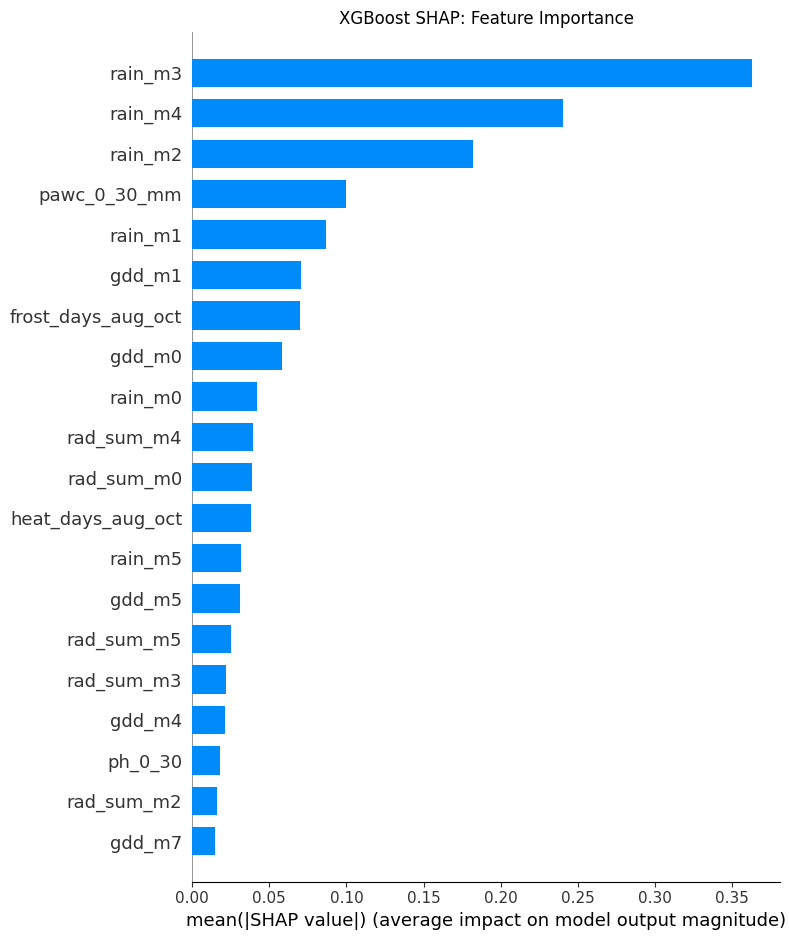

In [49]:
# Global importance
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, feature_names=MONTHLY_FEATURES,
                  plot_type="bar", max_display=20, show=False)
plt.title("XGBoost SHAP: Feature Importance")
plt.tight_layout()
plt.show()

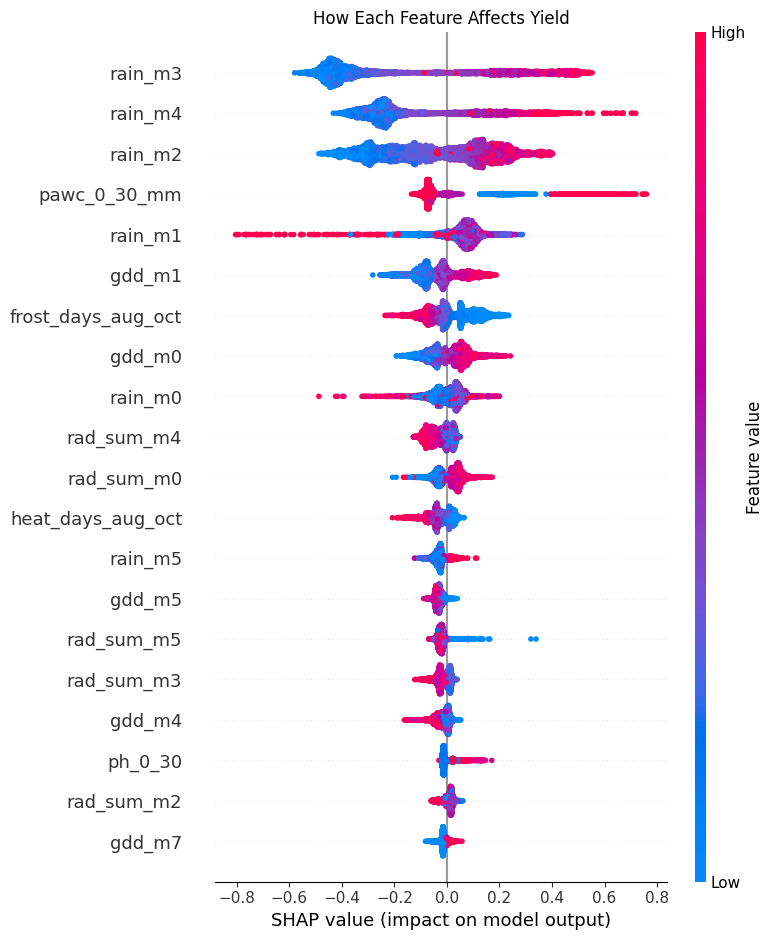

Reading the beeswarm:
  Red dots  = high values of that feature
  Blue dots = low values of that feature
  Right     = pushes yield UP
  Left      = pushes yield DOWN


In [50]:
# Beeswarm: direction of effect 
# Red = high feature value, Blue = low
# Right = pushes yield UP, Left = pushes yield DOWN

fig = plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap, feature_names=MONTHLY_FEATURES,
                  max_display=20, show=False)
plt.title("How Each Feature Affects Yield")
plt.tight_layout()
plt.show()

print("Reading the beeswarm:")
print("  Red dots  = high values of that feature")
print("  Blue dots = low values of that feature")
print("  Right     = pushes yield UP")
print("  Left      = pushes yield DOWN")

=== High yield cell ===
Actual: 4.23 t/ha   Predicted: 3.65 t/ha


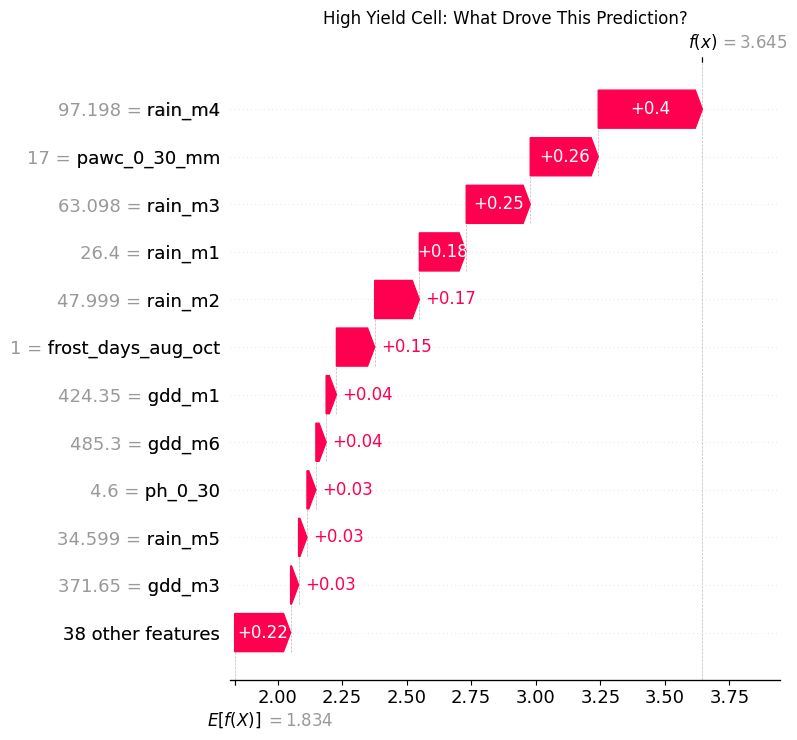

In [51]:
# Waterfall: explain individual predictions 

high_idx = np.argmax(actual_test[shap_idx])
low_idx  = np.argmin(actual_test[shap_idx])

print(f"=== High yield cell ===")
print(f"Actual: {actual_test[shap_idx[high_idx]]:.2f} t/ha   "
      f"Predicted: {pred_xgb_m[shap_idx[high_idx]]:.2f} t/ha")

fig = plt.figure(figsize=(14, 4))
shap.waterfall_plot(
    shap.Explanation(values=shap_values[high_idx],
                     base_values=explainer.expected_value,
                     data=X_shap[high_idx],
                     feature_names=MONTHLY_FEATURES),
    max_display=12, show=False)
plt.title("High Yield Cell: What Drove This Prediction?")
plt.tight_layout()
plt.show()

=== Low yield cell ===
Actual: 0.04 t/ha   Predicted: 1.42 t/ha


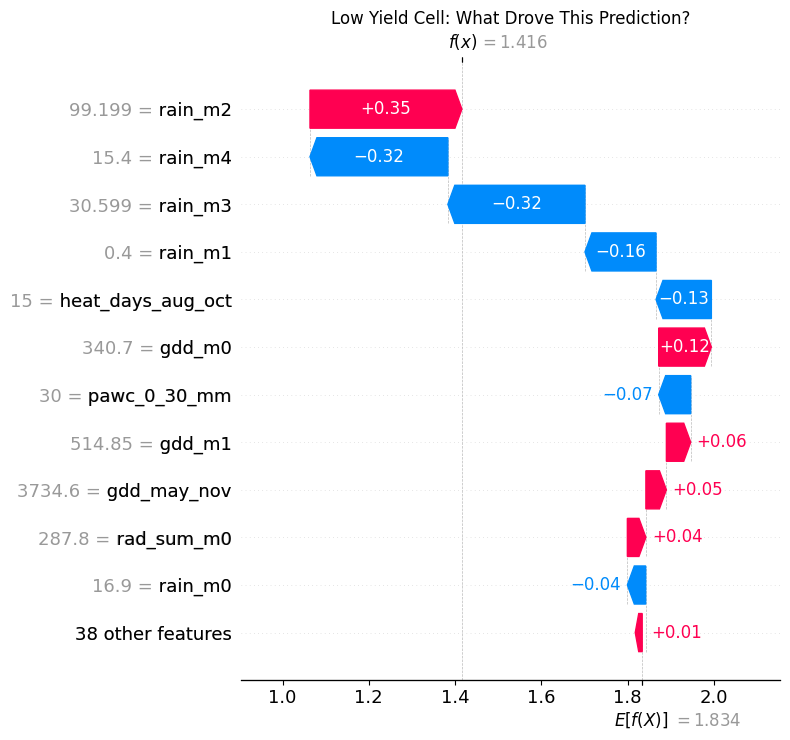

In [52]:
print(f"=== Low yield cell ===")
print(f"Actual: {actual_test[shap_idx[low_idx]]:.2f} t/ha   "
      f"Predicted: {pred_xgb_m[shap_idx[low_idx]]:.2f} t/ha")

fig = plt.figure(figsize=(14, 4))
shap.waterfall_plot(
    shap.Explanation(values=shap_values[low_idx],
                     base_values=explainer.expected_value,
                     data=X_shap[low_idx],
                     feature_names=MONTHLY_FEATURES),
    max_display=12, show=False)
plt.title("Low Yield Cell: What Drove This Prediction?")
plt.tight_layout()
plt.show()

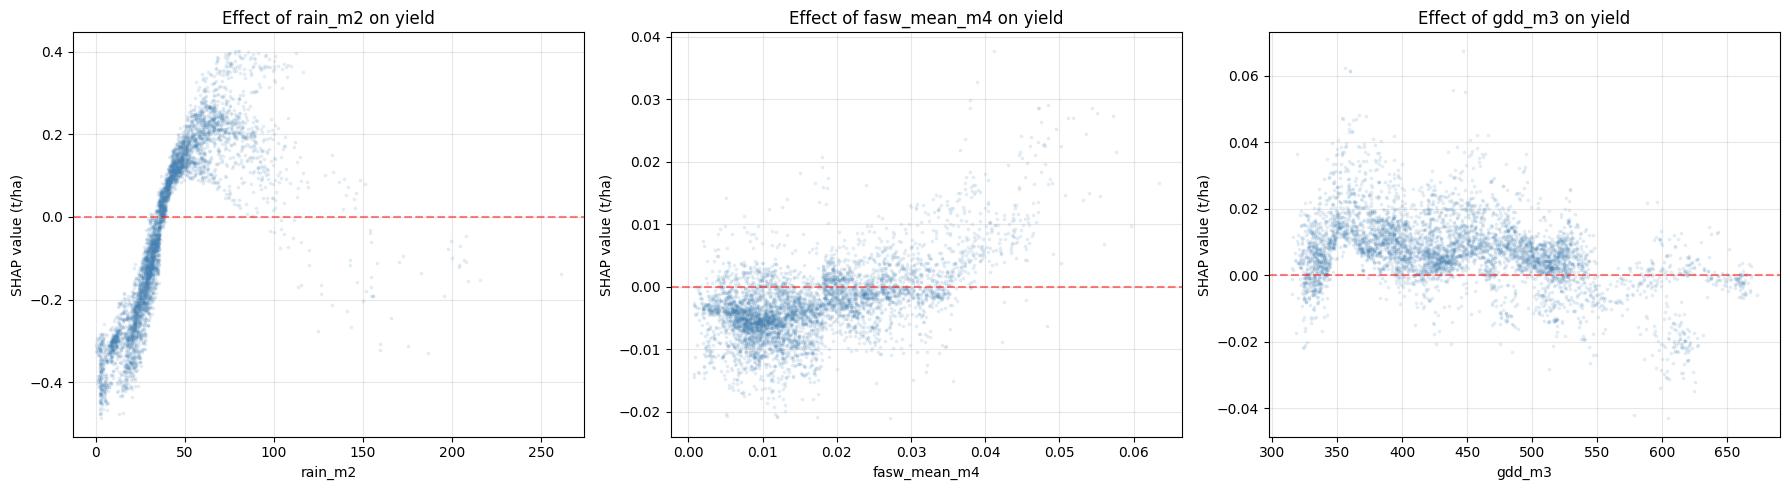

  The curve shape shows how the feature affects yield
  Flat regions = feature does not matter at those values
  Steep regions = feature is critical


In [59]:
# ── SHAP dependence plot: explore one feature ──
# Shows how a single feature's value relates to its SHAP value

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, ["rain_m2", "fasw_mean_m4", "gdd_m3"]):
    if feat in MONTHLY_FEATURES:
        fi = MONTHLY_FEATURES.index(feat)
        ax.scatter(X_shap[:, fi], shap_values[:, fi], alpha=0.1, s=3, color='steelblue')
        ax.axhline(0, color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel(feat)
        ax.set_ylabel(f"SHAP value (t/ha)")
        ax.set_title(f"Effect of {feat} on yield")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("  The curve shape shows how the feature affects yield")
print("  Flat regions = feature does not matter at those values")
print("  Steep regions = feature is critical")

**Discussion:**
1. Look at the beeswarm — which features have the clearest direction of effect?
2. In the waterfall plots, what drove the high-yield vs low-yield predictions?
3. Do the SHAP results match your agronomic understanding of WA wheat?
4. Which months matter most for rainfall? For soil moisture?


## Learning rate and depth effects 

The two most important XGBoost hyperparameters:
- **learning_rate** ($\eta$): how much each tree contributes (smaller = more robust)
- **max_depth**: tree complexity (shallower = less overfitting)


In [31]:
# Effect of learning rate 
lr_results = []
for lr in [0.01, 0.05, 0.1, 0.2, 0.3]:
    model = xgb.XGBRegressor(
        n_estimators=1000, max_depth=6, learning_rate=lr,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
        random_state=42, n_jobs=-1, tree_method="hist",
        early_stopping_rounds=50)
    model.fit(X_tr_m, y_tr_m, eval_set=[(X_val_m, y_val_m)], verbose=False)
    pred = model.predict(X_test_m)
    lr_results.append({
        "learning_rate": lr,
        "best_trees": model.best_iteration,
        "R2": r2_score(actual_test, pred),
        "RMSE": np.sqrt(mean_squared_error(actual_test, pred))
    })

lr_df = pd.DataFrame(lr_results)
print(lr_df.to_string(index=False))


 learning_rate  best_trees       R2     RMSE
          0.01         999 0.797513 0.396935
          0.05         999 0.819078 0.375204
          0.10         999 0.821519 0.372664
          0.20         999 0.796248 0.398174
          0.30         999 0.776484 0.417038


In [54]:
# Effect of max_depth 
depth_results = []
for d in [3, 4, 5, 6, 8, 10]:
    model = xgb.XGBRegressor(
        n_estimators=2000, max_depth=d, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
        random_state=42, n_jobs=-1, tree_method="hist",
        early_stopping_rounds=50)
    model.fit(X_tr_m, y_tr_m, eval_set=[(X_val_m, y_val_m)], verbose=False)
    pred = model.predict(X_test_m)
    depth_results.append({
        "max_depth": d,
        "best_trees": model.best_iteration,
        "R2": r2_score(actual_test, pred),
        "RMSE": np.sqrt(mean_squared_error(actual_test, pred))
    })

depth_df = pd.DataFrame(depth_results)
print(depth_df.to_string(index=False))


 max_depth  best_trees       R2     RMSE
         3        1999 0.816484 0.377884
         4        1999 0.815522 0.378873
         5        1998 0.818383 0.375924
         6        1999 0.823345 0.370753
         8        1999 0.805017 0.389511
        10        1999 0.815771 0.378617



### Exercises
1. Use `shap.dependence_plot` to explore how `rain_m0` (sowing month rain) affects yield. Is there a saturation point?
2. Compare SHAP values for 2019 vs 2020 separately. Do the important features change between years?
3. Try `max_depth=4` with `learning_rate=0.01` and 5000 estimators. Does a shallower, slower model do better?

